Found 1 range-doppler files

Loading: range_doppler_2026-05-31_11-57-41.csv
Shape: (1024, 8192)
Peak Doppler Bin: 123
Peak Range Bin  : 655


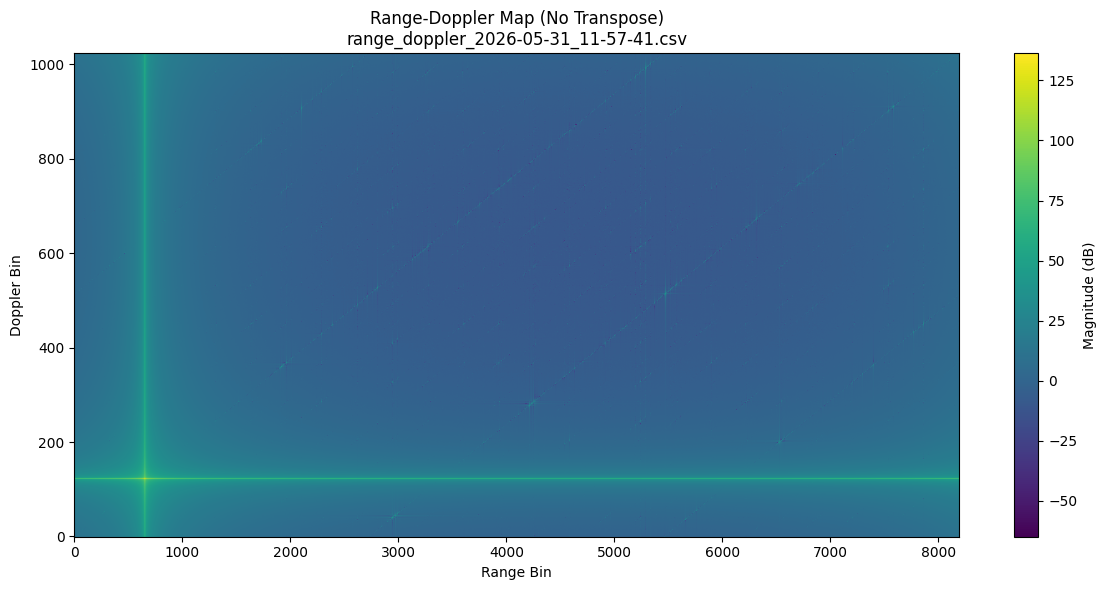

In [3]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Locate CSV files
# -----------------------------------------------------------------------------

data_dir = pathlib.Path("data")

csv_files = sorted(data_dir.glob("*.csv"))

if not csv_files:
    raise RuntimeError("No CSV files found in ./data")

print(f"Found {len(csv_files)} range-doppler files")

# -----------------------------------------------------------------------------
# Plot
# -----------------------------------------------------------------------------

for csv_file in csv_files:

    print(f"\nLoading: {csv_file.name}")

    data = np.loadtxt(csv_file, delimiter=",")

    print(f"Shape: {data.shape}")

    peak = np.unravel_index(np.argmax(data), data.shape)

    print(f"Peak Doppler Bin: {peak[0]}")
    print(f"Peak Range Bin  : {peak[1]}")

    data_db = 20.0 * np.log10(data + 1e-12)

    plt.figure(figsize=(12, 6))

    plt.imshow(
        data_db,
        aspect="auto",
        origin="lower",
        interpolation="nearest"
    )

    plt.colorbar(label="Magnitude (dB)")

    plt.xlabel("Range Bin")
    plt.ylabel("Doppler Bin")

    plt.title(
        f"Range-Doppler Map (No Transpose)\n"
        f"{csv_file.name}"
    )

    plt.tight_layout()

plt.show()